# Session 2: time dependent data

Welcome to the second session of the Data Analysis workshop for Complex Systems course.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from func import *

sns.set_theme(style="whitegrid")


## Diagnostic Tools: Rolling Mean, Rolling Standard Deviation, and Moving Averages

Recall the measurement model $x_{\text{observed}} = x_{\text{true}} + \epsilon$ from earlier.  
To smooth out random noise $\epsilon$ and reveal the underlying trend, we used a **moving average**:

$$
y_t = \frac{1}{k}\sum_{i=0}^{k-1} x_{t-i}.
$$

This same idea – averaging over a sliding window – gives us powerful diagnostic tools to **see** whether the properties of a time series are stable over time.

### Rolling window
A window of size $w$ moves one step at a time across the series. At each position, we compute a summary statistic from the $w$ observations inside that window.

### Rolling mean
The **rolling mean** (backward‑looking) at time $t$ is the average of the most recent $w$ observations:

$$
\text{RollMean}_t = \frac{1}{w}\sum_{i=t-w+1}^{t} X_i .
$$

- If the true mean is constant, the rolling mean will hover around that constant.
- A persistent upward or downward slope in the rolling mean signals a **changing mean** – a violation of stationarity.

### Rolling standard deviation
The **rolling standard deviation** measures the spread within the window:

$$
\text{RollStd}_t = \sqrt{\frac{1}{w}\sum_{i=t-w+1}^{t} (X_i - \overline{X}_t)^2}.
$$

- A stable rolling std suggests constant variance.
- Large swings or a long‑term drift in rolling std indicate **time‑varying volatility**, another failure of stationarity.

### Simple Moving Average (SMA) vs. rolling mean
A **simple moving average** is essentially a rolling mean. In practice, we often **centre** the window (using an equal number of past and future values) to smooth the series and extract historical trends without introducing a time shift. By contrast, the backward‑looking rolling mean (as defined above) is used for real‑time monitoring and diagnostic checks.

These diagnostics will be our first line of defence when judging whether a series can be treated as stationary.

### 1. Marginal distribution
The **marginal distribution** of a single random variable $X_t$ describes the probability of its values without reference to any other point in time.  
For example, if we look at all daily returns ignoring their date, the histogram we draw is an estimate of the marginal distribution.


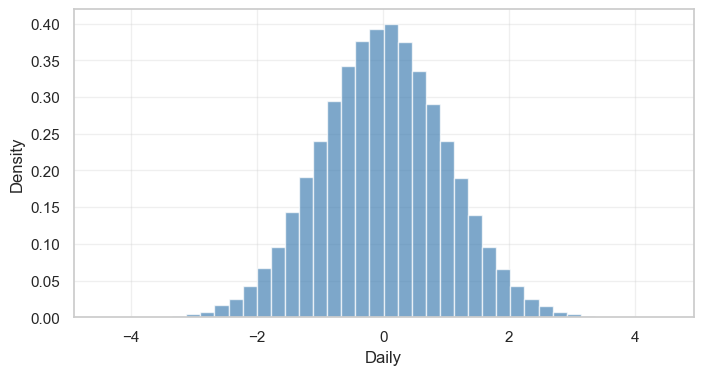

In [5]:
values = np.random.normal(loc=0, scale=1, size=100000) 

#print(values)

plt.figure(figsize=(8, 4))
plt.hist(values, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='white')
plt.xlabel('Daily')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.show()

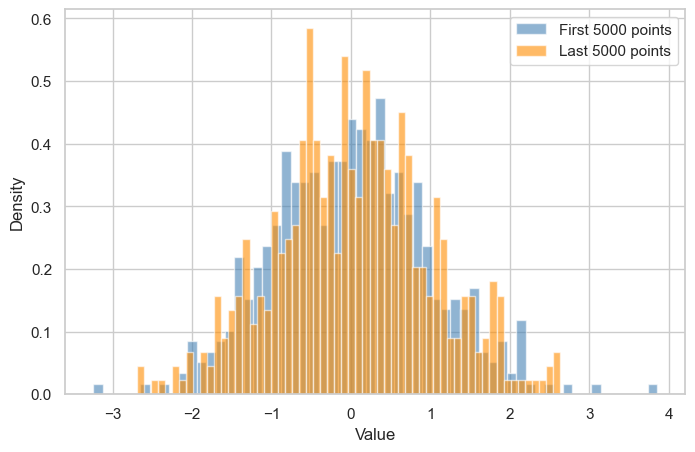

In [6]:
n = 1000
mu,var= 0, 1
np.random.seed(42)
series = np.random.normal( loc=mu,scale=var, size=n)

window_size = n // 2
window1 = series[:window_size]          
window2 = series[-window_size:]         

plt.figure(figsize=(8,5))
plt.hist(window1, bins=60, density=True, alpha=0.6, label='First 5000 points', color='steelblue')
plt.hist(window2, bins=60, density=True, alpha=0.6,label='Last 5000 points', color='darkorange')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

### 2. Joint distribution

The **joint distribution** of several random variables (e.g. $X_t$ and $X_{t+1}$)  
characterises how they behave together – it captures correlation, co‑movement, and higher‑order dependencies.

- **Joint probability density function (joint PDF)** – describes the relative likelihood of observing a combination of values.
- **Joint cumulative distribution function (joint CDF)** – $F(x,y) = P(X \le x,\; Y \le y)$, the probability that $X$ is at most $x$ **and** $Y$ is at most $y$.



***

## Strict (Strong) Stationarity

A time series $\{X_t\}$ is **strictly stationary** if the joint cumulative distribution function of every finite collection of its values is invariant under a common time shift.  
Formally, for any $k\geq 1$, any times $t_1,\dots,t_k$, and any lag $h$,

$$
F_{t_1,\dots,t_k}(x_1,\dots,x_k) \;=\; F_{t_1+h,\dots,t_k+h}(x_1,\dots,x_k).
$$

**Intuition**  
The entire probabilistic structure – all dependencies, all distributional shapes – stays exactly the same over time. Two equally long blocks taken from different periods are statistically indistinguishable.

**Consequences**  
If the necessary moments exist:
- Mean, variance, skewness, kurtosis, and all higher‑order cumulants are constant across time.
- Any summary statistic computed on one part of the series will, on average, equal the same statistic computed on any other part of equal length.
- The marginal distribution of $X_t$ is identical for every $t$.

An i.i.d. sequence drawn from a fixed distribution is automatically strictly stationary.

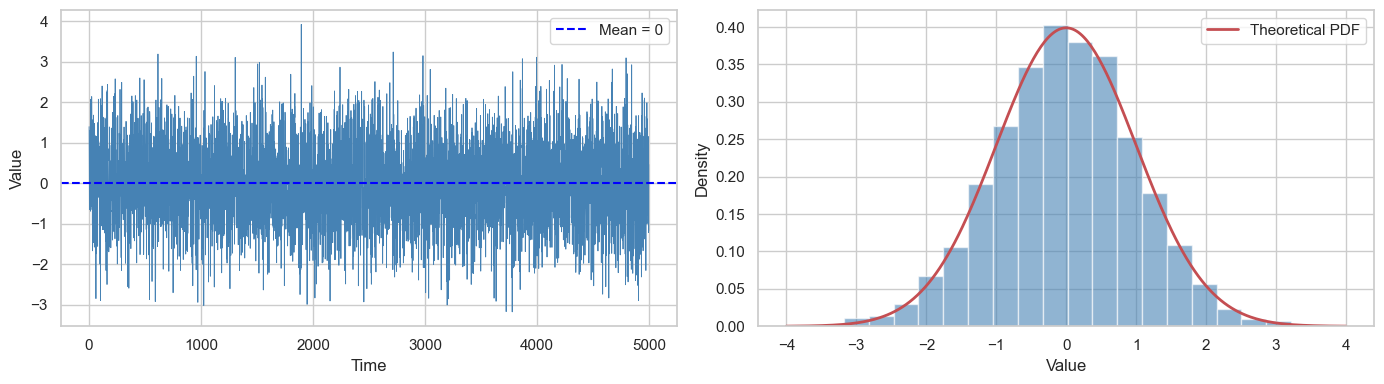

First half statistics:  mean = 0.0270, var = 1.0006, skew = -0.0129, kurt = 0.0153
Second half statistics: mean = -0.0422, var = 1.0056, skew = -0.0127, kurt = 0.0467


In [7]:
n = 5000
mu, sigma = 0, 1
strong_stationary = np.random.normal(mu, sigma, size=n)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(strong_stationary, linewidth=0.6, color='steelblue')
axes[0].axhline(mu, color='blue', linestyle='--', label=f'Mean = {mu}')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Value')
axes[0].legend()

axes[1].hist(strong_stationary, bins=20, density=True, alpha=0.6, edgecolor='white', color='steelblue')
x_pdf = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
axes[1].plot(x_pdf, stats.norm.pdf(x_pdf, mu, sigma), 'r-', lw=2, label='Theoretical PDF')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()


half = n // 2
first_half  = strong_stationary[:half]
second_half = strong_stationary[half:]

print("First half statistics:  mean = {:.4f}, var = {:.4f}, skew = {:.4f}, kurt = {:.4f}".format(
    get_mean(first_half), get_variance(first_half), get_skewness(first_half), get_kurtosis(first_half)
))
print("Second half statistics: mean = {:.4f}, var = {:.4f}, skew = {:.4f}, kurt = {:.4f}".format(
    get_mean(second_half), get_variance(second_half), get_skewness(second_half), get_kurtosis(second_half)
))

## Weak Stationarity (Covariance Stationarity)

A time series $\{X_t\}$ is **weakly stationary** if, for all $t$ and all lags $h$:

1. **Constant mean** – $\mathbb{E}[X_t] = \mu$ (independent of $t$).
2. **Constant variance** – $\mathrm{Var}(X_t) = \sigma^2$ (independent of $t$).
3. **Autocovariance depends only on lag** – $\mathrm{Cov}(X_t, X_{t+h}) = \gamma(h)$ (a function of $h$ alone, not of $t$).

Weak stationarity makes no restriction on higher‑order moments (skewness, kurtosis) or on the full shape of the distribution.

**Relation to strict stationarity:**  
Strict stationarity + finite second moments → weak stationarity.  
The converse is **not** true: a process can be weakly stationary while its distribution, beyond the first two moments, changes over time.

### Is this series stationary?

Consider the following six daily closing prices of a hypothetical stock:

$$
10,\; 11,\; 13,\; 16,\; 20,\; 25
$$

- Compute the average of the **first three** days.
- Compute the average of the **last three** days.
- Are they roughly the same?

If the mean is not constant over time, the series cannot be weakly stationary.

In [8]:
d= [10,11,13,16,20,25,15,13,14,122,1555,15]
listt= np.array(d)
print(get_mean(listt))

n= len(listt)
third = n// 3 

first= listt[:third]
print(get_mean(first))
sec= listt[third:2*third]
print(get_mean(sec))


thi= listt[2*third:]

print(get_mean(thi))


152.41666666666666
12.5
18.25
426.5


## Non‑Stationary Process

A time series is **non‑stationary** if it fails at least one of the three conditions for weak stationarity:

1. **Mean is not constant** – the series drifts or trends over time.
2. **Variance is not constant** – the spread of fluctuations changes (volatility clustering or structural breaks).
3. **Autocovariance depends on absolute time**, not only on lag – the memory structure evolves.

In practice, most economic and financial time series (prices, GDP, etc.) are non‑stationary because their level and/or volatility change across decades, business cycles, or market regimes.



## From non‑stationary prices to stationary returns (**maybe**)

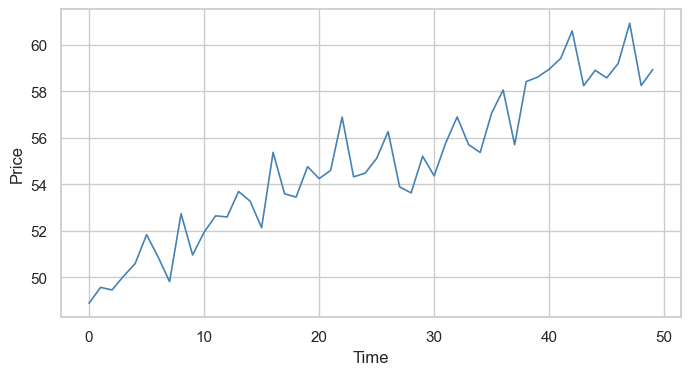

In [9]:
T = 50
t = np.arange(T)
slope = 0.2
noise = np.random.normal(0, 1.0, T)
price = 50 + slope * t + noise

plt.figure(figsize=(8,4))
plt.plot(t, price, linewidth=1.2, color='steelblue')
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()

Our goal is to **transform it into a stationary series as possible**

 What would you do to remove the trend and make the series fluctuate around a constant level?

### 1. Tilting – removing a linear trend



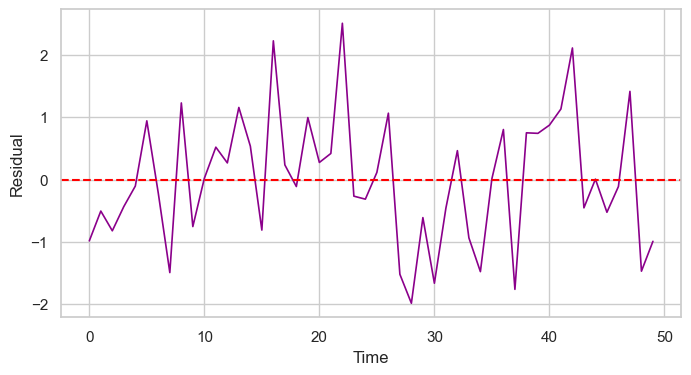

In [10]:

b, a = np.polyfit(t, price, 1)

tilted = price - (a + b * t)

plt.figure(figsize=(8,4))
plt.plot(t, tilted, linewidth=1.2, color='darkmagenta')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Residual')
plt.show()

### 2. First differences

Instead of fitting a global trend, we can look at **changes from one period to the next**:
$$\Delta P_t = P_t - P_{t-1}$$
This removes the trend locally but keeps the units of price.

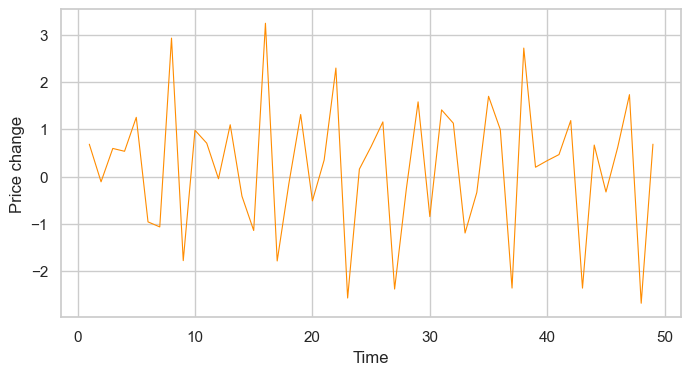

In [11]:
def first_diff(price_list):
    result = [np.nan]  
    for i in range(1, len(price_list)):
        diff = price_list[i] - price_list[i-1]
        result.append(diff)
    return result

if isinstance(price, np.ndarray):
    price_list = price.tolist()
else:
    price_list = list(price)

first_diff = first_diff(price_list)

plt.figure(figsize=(8,4))
plt.plot(t, first_diff, linewidth=0.8, color='darkorange')
plt.xlabel('Time')
plt.ylabel('Price change')
plt.show()

### 3. Simple returns (percentage changes)

Financial markets care about **relative** changes, not absolute ones.  
The simple return scales the change by the previous price:
$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$



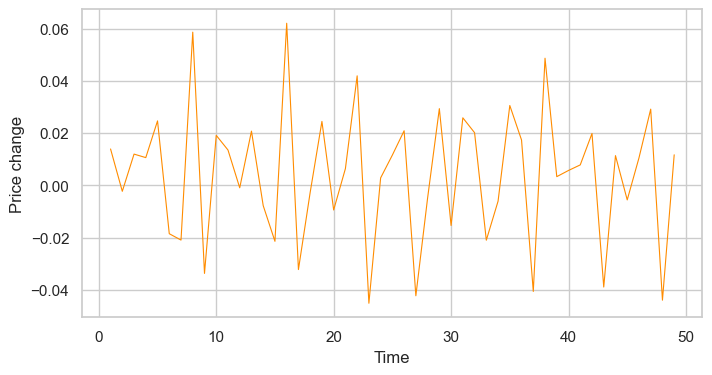

In [12]:
def first_diff(price_list):
    result = [np.nan]  
    for i in range(1, len(price_list)):
        diff = (price_list[i] - price_list[i-1] )/price_list[i-1] 
        result.append(diff)
    return result

if isinstance(price, np.ndarray):
    price_list = price.tolist()
else:
    price_list = list(price)

first_diff = first_diff(price_list)

plt.figure(figsize=(8,4))
plt.plot(t, first_diff, linewidth=0.8, color='darkorange')
plt.xlabel('Time')
plt.ylabel('Price change')
plt.show()

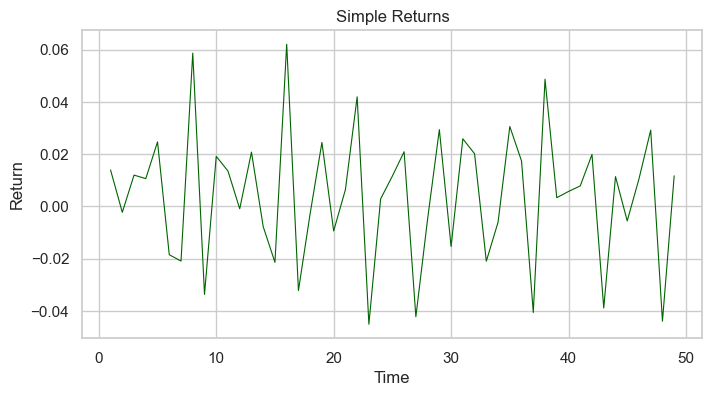

In [13]:
simple_ret = np.diff(price) / price[:-1]         
simple_ret = np.insert(simple_ret, 0, np.nan)     

plt.figure(figsize=(8,4))
plt.plot(t[1:], simple_ret[1:], linewidth=0.8, color='darkgreen')
plt.title('Simple Returns')
plt.xlabel('Time')
plt.ylabel('Return')
plt.show()

### 4. Side‑by‑side comparison


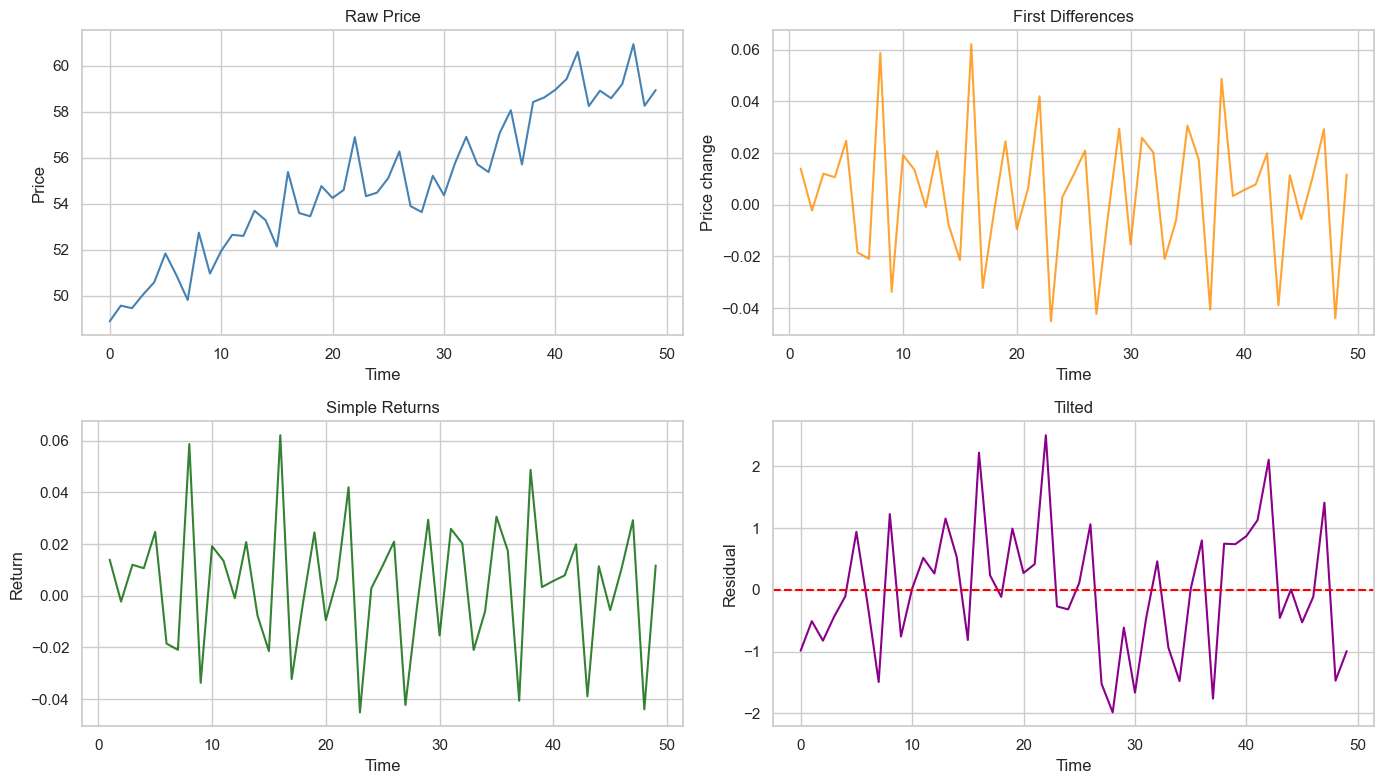

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(t, price, color='steelblue')
axes[0,0].set_title('Raw Price')
axes[0,0].set_xlabel('Time')
axes[0,0].set_ylabel('Price')

axes[0,1].plot(t[1:], first_diff[1:], color='darkorange', alpha=0.8)
axes[0,1].set_title('First Differences')
axes[0,1].set_xlabel('Time')
axes[0,1].set_ylabel('Price change')

axes[1,0].plot(t[1:], simple_ret[1:], color='darkgreen', alpha=0.8)
axes[1,0].set_title('Simple Returns')
axes[1,0].set_xlabel('Time')
axes[1,0].set_ylabel('Return')

axes[1,1].plot(t, tilted, color='darkmagenta')
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_title('Tilted')
axes[1,1].set_xlabel('Time')
axes[1,1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

# Loading the data

In [16]:
btc = pd.read_csv('BTCUSD_D.csv')
print(btc.head())
btc.head()

         time  open  high   low  close  tick_volume
0  2011-03-24  0.83  0.90  0.82   0.87        14009
1  2011-03-25  0.87  0.89  0.86   0.89         4819
2  2011-03-28  0.82  0.85  0.76   0.80        12565
3  2011-03-29  0.80  0.80  0.77   0.79         4215
4  2011-03-30  0.79  0.79  0.76   0.79         3218


,time,open,high,low,close,tick_volume
0,2011-03-24,0.83,0.90,0.82,0.87,14009
1,2011-03-25,0.87,0.89,0.86,0.89,4819
2,2011-03-28,0.82,0.85,0.76,0.80,12565
3,2011-03-29,0.80,0.80,0.77,0.79,4215
4,2011-03-30,0.79,0.79,0.76,0.79,3218


## Cleaning the data 

In [17]:
btc = btc[['time', 'close']].rename(columns={'time': 'Date', 'close': 'Close'})

btc['Date'] = pd.to_datetime(btc['Date'])

btc = btc.sort_values('Date').reset_index(drop=True)

print(btc.head())

        Date  Close
0 2011-03-24   0.87
1 2011-03-25   0.89
2 2011-03-28   0.80
3 2011-03-29   0.79
4 2011-03-30   0.79


In [18]:
print("Data types of each column:")
print(btc.dtypes)

print("\nMissing values per column:")
print(btc.isnull().sum())

print("\nNumber of rows after cleaning:", len(btc))
print("Date range: from", btc['Date'].min(), "to", btc['Date'].max())

Data types of each column:
Date     datetime64[ns]
Close           float64
dtype: object

Missing values per column:
Date     0
Close    0
dtype: int64

Number of rows after cleaning: 2762
Date range: from 2011-03-24 00:00:00 to 2021-06-15 00:00:00


## visualizing

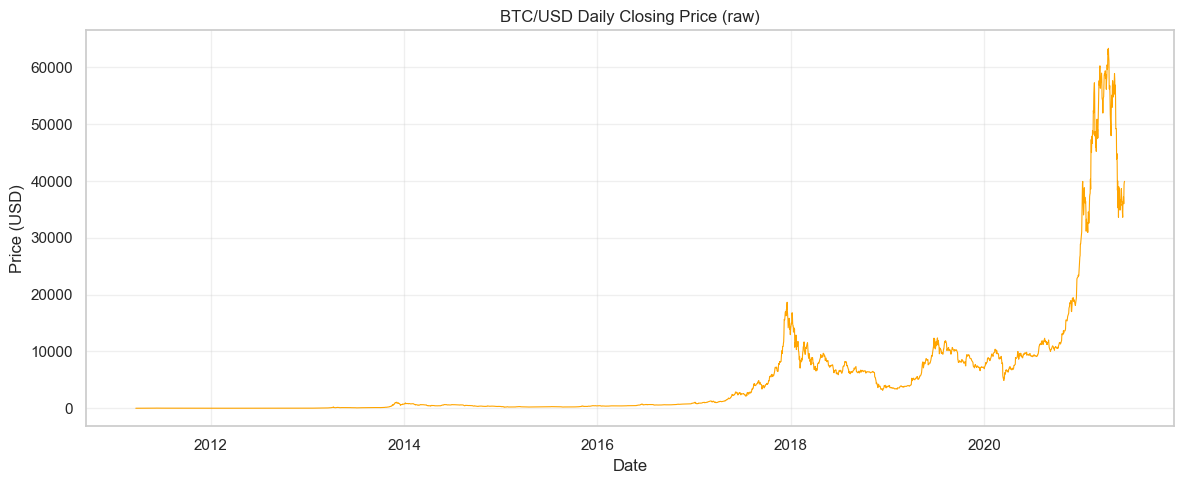

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(btc['Date'], btc['Close'], linewidth=0.8, color='orange')
plt.title('BTC/USD Daily Closing Price (raw)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# is it stationary?

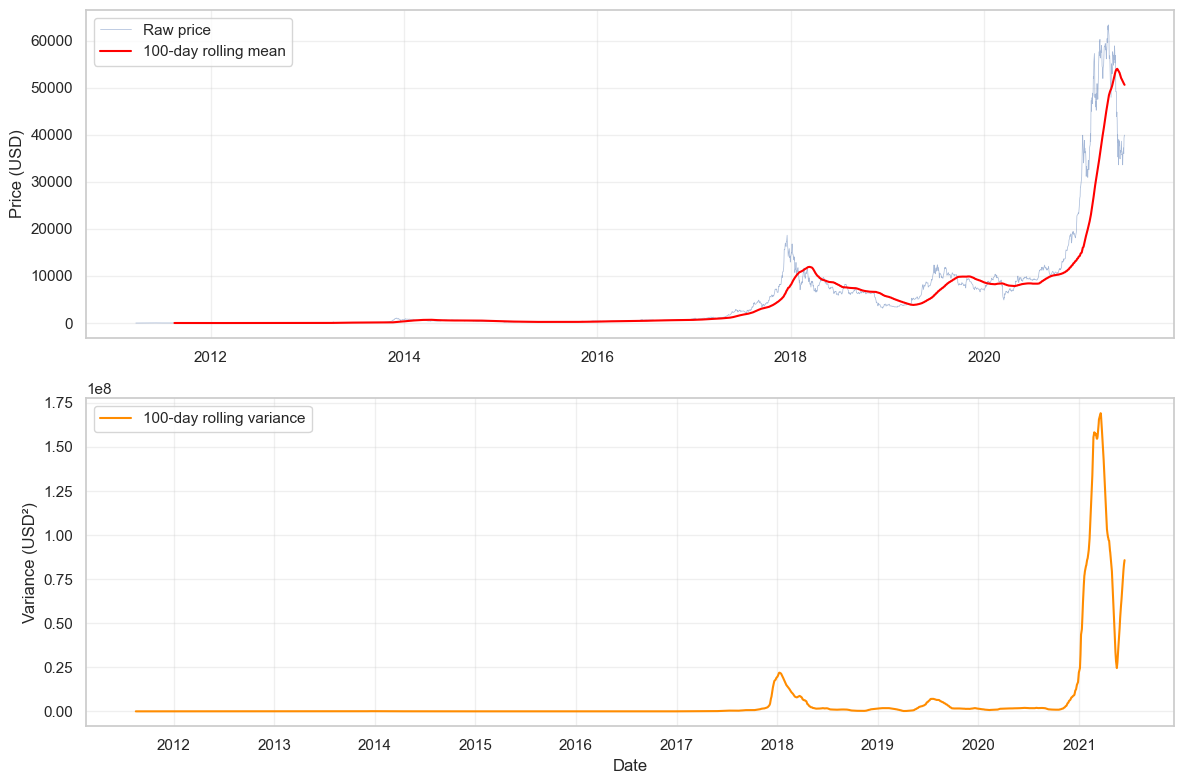

In [20]:
window = 100

btc['Roll_Mean'] = btc['Close'].rolling(window).mean()
btc['Roll_Var'] = btc['Close'].rolling(window).var()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(btc['Date'], btc['Close'], linewidth=0.5, alpha=0.5, label='Raw price')
ax1.plot(btc['Date'], btc['Roll_Mean'], color='red', linewidth=1.5, label=f'{window}-day rolling mean')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(btc['Date'], btc['Roll_Var'], color='darkorange', linewidth=1.5, label=f'{window}-day rolling variance')
ax2.set_ylabel('Variance (USD²)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



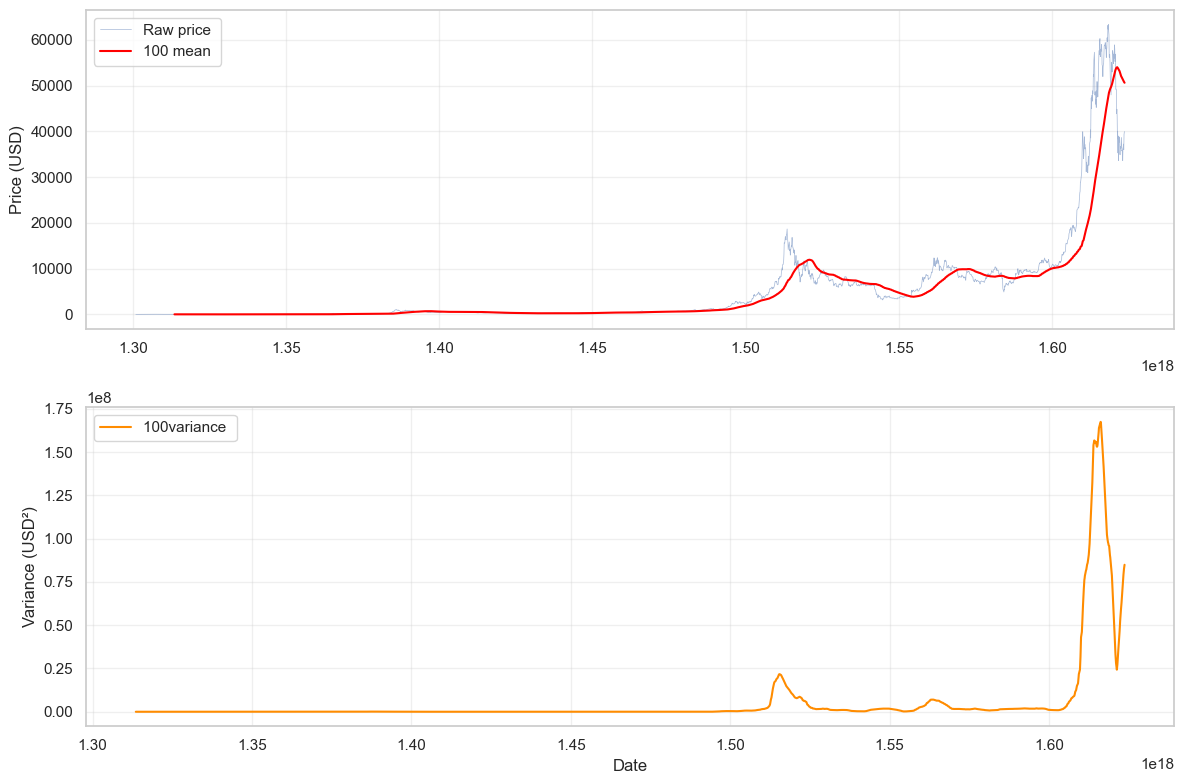

In [21]:
window = 100

prices = btc['Close'].values.tolist()
dates = btc['Date'].values.tolist()

roll_means = rolling_mean(prices, window)         
roll_vars  = rolling_variance(prices, window)      

roll_dates = dates[window-1:]                      

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(dates, prices, linewidth=0.5, alpha=0.5, label='Raw price')
ax1.plot(roll_dates, roll_means, color='red', linewidth=1.5, label=f'{window} mean ')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(roll_dates, roll_vars, color='darkorange', linewidth=1.5, label=f'{window}variance ')
ax2.set_ylabel('Variance (USD²)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

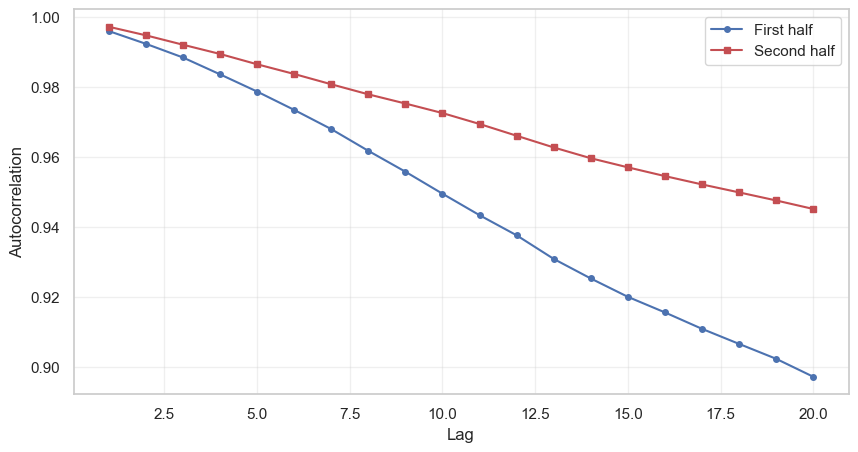

In [22]:
prices = btc['Close'].values.tolist()

mid = len(prices) // 2
first_half = prices[:mid]
second_half = prices[mid:]

acf1 = [get_autocorrelation(first_half, lag) for lag in range(1, 21)]
acf2 = [get_autocorrelation(second_half, lag) for lag in range(1, 21)]


plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), acf1, 'b-o', linewidth=1.5, markersize=4, label='First half')
plt.plot(range(1, 21), acf2, 'r-s', linewidth=1.5, markersize=4, label='Second half')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Simple returns

In [23]:
prices = btc['Close'].values.tolist()

returns = []
for i in range(1, len(prices)):
    ret = (prices[i] - prices[i-1]) / prices[i-1]
    returns.append(ret)

return_dates = btc['Date'].values[1:].tolist()


## moments of simple return

In [24]:
mean_ret = get_mean(returns)
var_ret = get_variance(returns)
std_ret = get_std(returns)
skew_ret = get_skewness(returns)
kurt_ret = get_kurtosis(returns)

print("===== Simple returns of Bitcoin (manual functions) =====")
print(f"Mean:     {mean_ret:.6f}")
print(f"Variance: {var_ret:.6f}")
print(f"Std dev:  {std_ret:.6f}")
print(f"Skewness: {skew_ret:.4f}")
print(f"Kurtosis: {kurt_ret:.4f}")

===== Simple returns of Bitcoin (manual functions) =====
Mean:     0.005422
Variance: 0.003121
Std dev:  0.055870
Skewness: 1.0005
Kurtosis: 12.3859


## rolling mean and variance

In [25]:

window = 50
roll_mean_vals = rolling_mean(returns, window)
roll_var_vals = rolling_variance(returns, window)

roll_dates = return_dates[window-1:]

print(f"Rolling mean (first 5): {roll_mean_vals[:5]}")
print(f"Rolling variance (first 5): {roll_var_vals[:5]}")

Rolling mean (first 5): [0.0574578020296783, 0.06396029606567917, 0.07194497931239055, 0.07798473672478948, 0.08273390060438814]
Rolling variance (first 5): [0.014106990064281287, 0.015730556282999523, 0.01621827427730237, 0.01698567470824936, 0.017350123438831543]


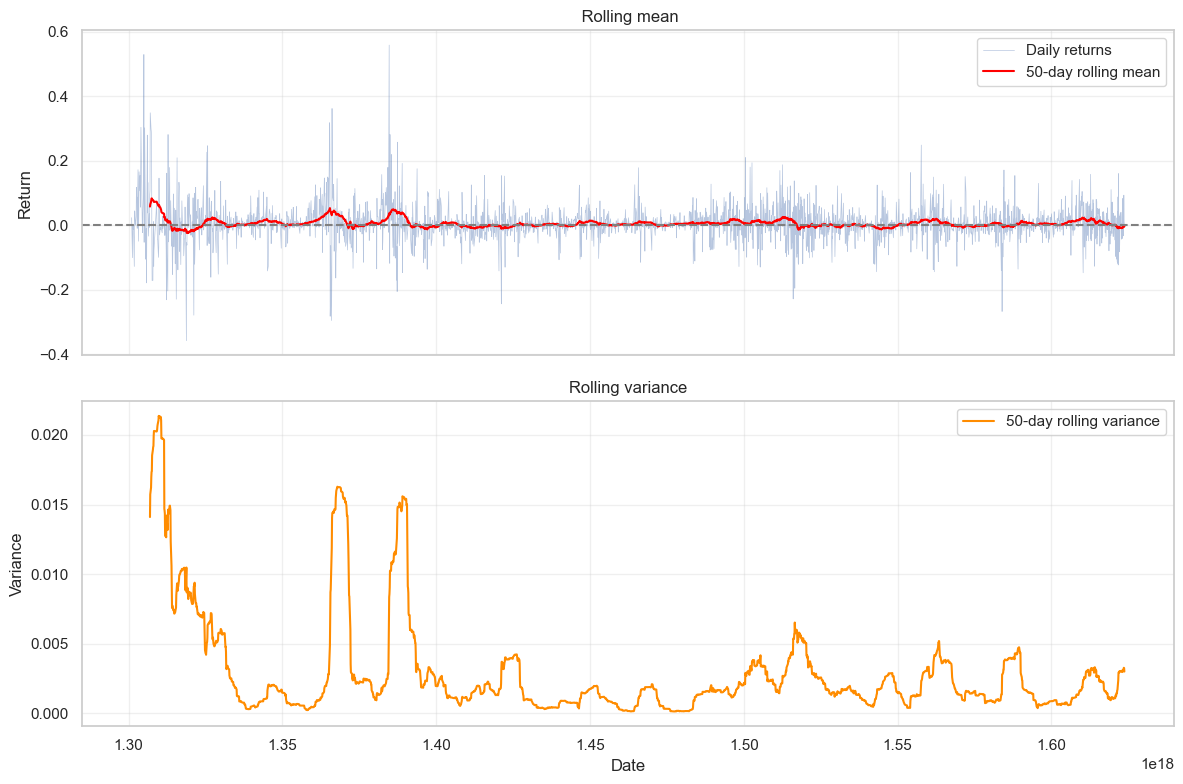

In [26]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(return_dates, returns, alpha=0.4, linewidth=0.5, label='Daily returns')
ax1.plot(roll_dates, roll_mean_vals, color='red', linewidth=1.5, label=f'{window}-day rolling mean')
ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel('Return')
ax1.legend()
ax1.set_title(' Rolling mean')
ax1.grid(alpha=0.3)

ax2.plot(roll_dates, roll_var_vals, color='darkorange', linewidth=1.5, label=f'{window}-day rolling variance')
ax2.set_ylabel('Variance')
ax2.set_xlabel('Date')
ax2.legend()
ax2.set_title('Rolling variance')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Compare moments

In [27]:
mid = len(returns) // 2
first_half = returns[:mid]
second_half = returns[mid:]

mean1 = get_mean(first_half)
var1 = get_variance(first_half)
skew1 = get_skewness(first_half)
kurt1 = get_kurtosis(first_half)

mean2 = get_mean(second_half)
var2 = get_variance(second_half)
skew2 = get_skewness(second_half)
kurt2 = get_kurtosis(second_half)

print("===== Statistics of first half vs second half (manual) =====")
print(f"{'Moment':<12} {'First half':<15} {'Second half':<15}")
print("-" * 45)
print(f"{'Mean':<12} {mean1:.6f}       {mean2:.6f}")
print(f"{'Variance':<12} {var1:.6f}       {var2:.6f}")
print(f"{'Skewness':<12} {skew1:.4f}          {skew2:.4f}")
print(f"{'Kurtosis':<12} {kurt1:.4f}          {kurt2:.4f}")

variance_ratio = var1 / var2
print(f"\nVariance ratio (first/second) = {variance_ratio:.3f}")
if 0.5 < variance_ratio < 2:
    print("Variances are relatively similar.")
else:
    print("Variances differ substantially → constant variance assumption likely violated.")

===== Statistics of first half vs second half (manual) =====
Moment       First half      Second half    
---------------------------------------------
Mean         0.006801       0.004043
Variance     0.004138       0.002102
Skewness     1.2647          0.0426
Kurtosis     12.6112          3.9599

Variance ratio (first/second) = 1.968
Variances are relatively similar.


Thanks.